# Fraud detection

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,auc,
                             average_precision_score, f1_score, confusion_matrix,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)


In [60]:
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 30)

In [61]:
train = pd.read_csv(r"C:\Users\Brahim\OneDrive\Bureau\DATA SCIENCE\PRACTICA_DB\Fraud_detection\train.csv")
test = pd.read_csv(r"C:\Users\Brahim\OneDrive\Bureau\DATA SCIENCE\PRACTICA_DB\Fraud_detection\test.csv")


In [62]:
train.shape, test.shape

((1296675, 23), (555719, 23))

In [63]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [64]:
train = train.drop(columns="Unnamed: 0")
test = test.drop(columns="Unnamed: 0")

In [65]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  str    
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  str    
 3   category               1296675 non-null  str    
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  str    
 6   last                   1296675 non-null  str    
 7   gender                 1296675 non-null  str    
 8   street                 1296675 non-null  str    
 9   city                   1296675 non-null  str    
 10  state                  1296675 non-null  str    
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               129667

Basic stats funtion definition 

In [66]:
def stats(df):
    stats = []
    for col in df.columns:
        stats.append((col,df[col].nunique(), df[col].isnull().sum(), df[col].isnull().sum()*100/df.shape[0], round(100*df[col].value_counts(normalize=True).values[0],3), df[col].dtype))
    stats_df = pd.DataFrame(stats, columns= ["column_name","unique_val","n_nulls","proportion_nulls","prportion_comun_val","dtype"])

    return stats_df

In [67]:
stats_train = stats(train)

In [68]:
stats_train

,column_name,unique_val,n_nulls,proportion_nulls,prportion_comun_val,dtype
0,trans_date_trans_time,1274791,0,0.0,0.000,str
1,cc_num,983,0,0.0,0.241,int64
2,merchant,693,0,0.0,0.340,str
3,category,14,0,0.0,10.154,str
4,amt,52928,0,0.0,0.042,float64
5,first,352,0,0.0,2.057,str
6,last,481,0,0.0,2.221,str
7,gender,2,0,0.0,54.745,str
8,street,983,0,0.0,0.241,str
9,city,894,0,0.0,0.433,str


# EDA

In [69]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  str    
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  str    
 3   category               1296675 non-null  str    
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  str    
 6   last                   1296675 non-null  str    
 7   gender                 1296675 non-null  str    
 8   street                 1296675 non-null  str    
 9   city                   1296675 non-null  str    
 10  state                  1296675 non-null  str    
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               129667

In [70]:
stats_train

,column_name,unique_val,n_nulls,proportion_nulls,prportion_comun_val,dtype
0,trans_date_trans_time,1274791,0,0.0,0.000,str
1,cc_num,983,0,0.0,0.241,int64
2,merchant,693,0,0.0,0.340,str
3,category,14,0,0.0,10.154,str
4,amt,52928,0,0.0,0.042,float64
5,first,352,0,0.0,2.057,str
6,last,481,0,0.0,2.221,str
7,gender,2,0,0.0,54.745,str
8,street,983,0,0.0,0.241,str
9,city,894,0,0.0,0.433,str


In [71]:
train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [72]:
train["is_fraud"].value_counts(normalize= True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

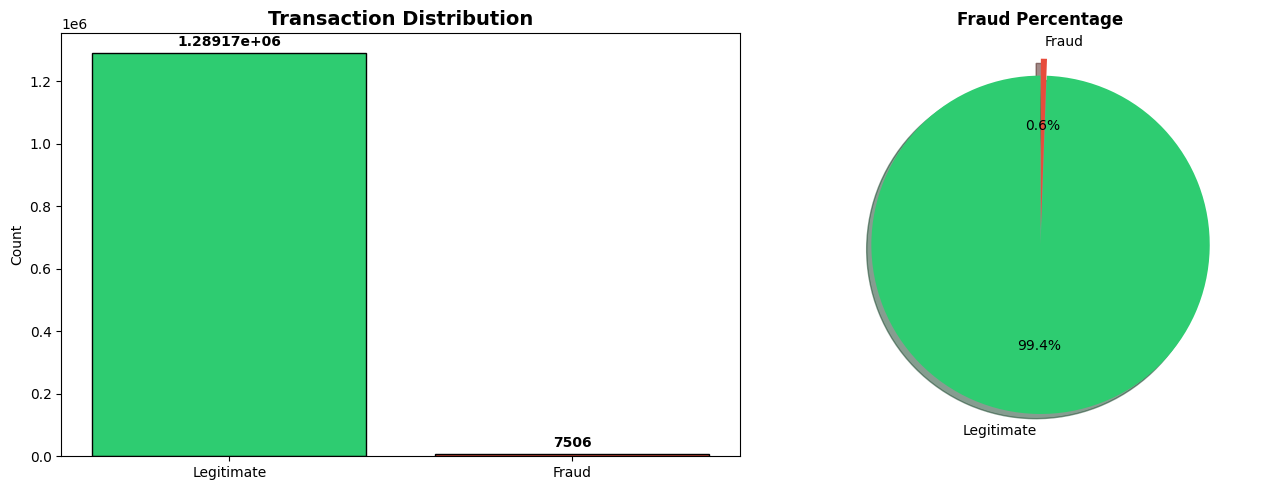

In [73]:
labels = ['Legitimate', 'Fraud'] # List format for plotting
colors = ['#2ecc71', '#e74c3c']

# 2. Create the layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Bar Chart ---
bars = axes[0].bar(labels, train["is_fraud"].value_counts(), color=colors, edgecolor='black')
axes[0].set_title('Transaction Distribution', fontweight='bold', fontsize=14)
axes[0].bar_label(bars, padding=3, fontweight='bold')
axes[0].set_ylabel('Count')

# --- Right Plot: Pie Chart ---
axes[1].pie(train["is_fraud"].value_counts(), labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, explode=(0, 0.1), shadow=True)
axes[1].set_title('Fraud Percentage', fontweight='bold')

plt.tight_layout()
plt.show()



## time analyse

In [74]:
for df in [train, test]:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])

In [75]:
tm_train = train.copy()

In [76]:
tm_train["hour"] = tm_train["trans_date_trans_time"].dt.hour
tm_train["dayofweek"] = tm_train["trans_date_trans_time"].dt.dayofweek
tm_train["month"] = tm_train["trans_date_trans_time"].dt.month
tm_train["day_name"] = tm_train["trans_date_trans_time"].dt.day_name()

When Happen the fraud?

In [77]:
fraud_hour = tm_train.groupby("hour")["is_fraud"].mean().reset_index()
fraud_hour.columns = ["hour","fraud_ratio_(%)"]
fraud_hour["fraud_ratio_(%)"] = fraud_hour["fraud_ratio_(%)"]*100

fraud_day = tm_train.groupby("day_name")["is_fraud"].mean().reset_index()
fraud_day.columns = ["day","fraud_ratio_(%)"]
fraud_day["fraud_ratio_(%)"] = fraud_day["fraud_ratio_(%)"]*100

orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fraud_day["day"] = pd.Categorical(fraud_day["day"], categories=orden, ordered=True)
fraud_day = fraud_day.sort_values("day").reset_index(drop=True)

monthly = tm_train.groupby('month')['is_fraud'].mean().reset_index()
monthly.columns = ["month", "fraud_ratio_(%)"]
monthly["fraud_ratio_(%)"]= monthly['fraud_ratio_(%)']*100


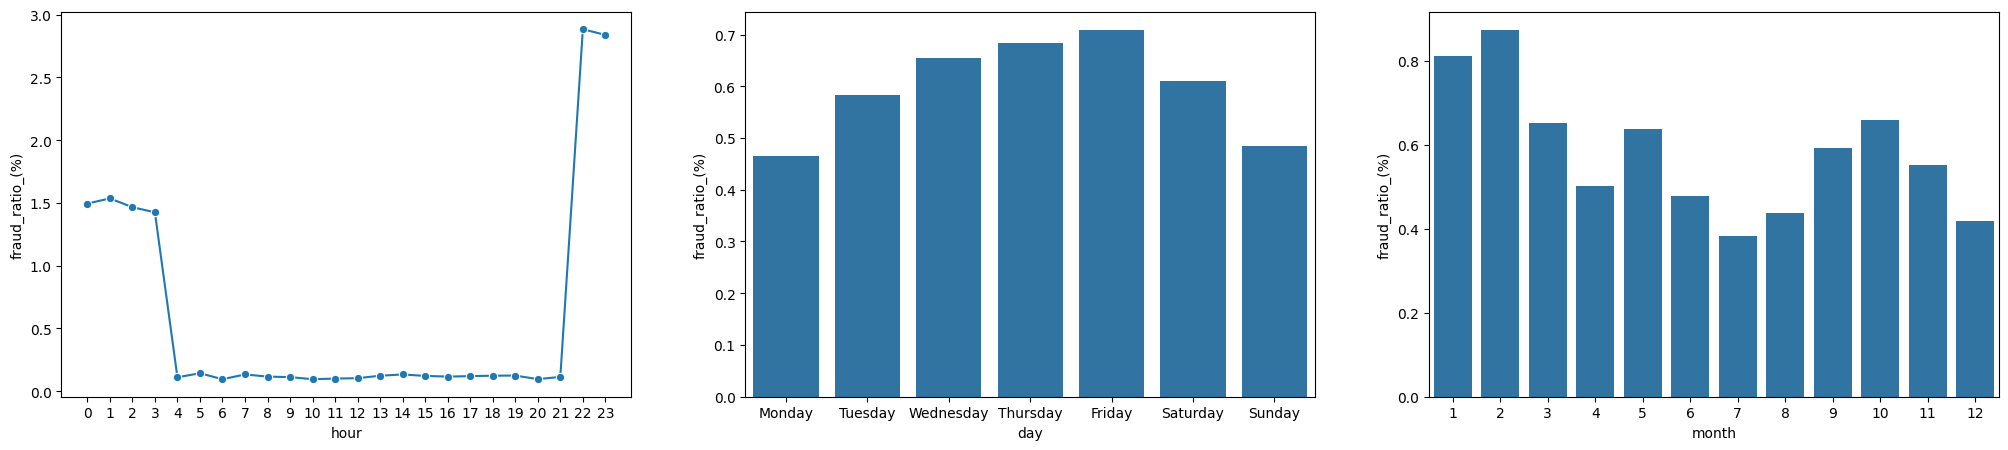

In [78]:
fig, axes = plt.subplots(nrows=1,ncols=3, figsize=(25,5),squeeze=False)


sns.lineplot(data= fraud_hour,x="hour", y="fraud_ratio_(%)", ax=axes[0,0],marker="o")
sns.barplot(data=fraud_day ,x="day", y="fraud_ratio_(%)", ax=axes[0,1])
sns.barplot(data=monthly,x="month",y= "fraud_ratio_(%)", ax=axes[0,2])

# Mostrar todos los ticks del eje x
axes[0, 1].set_xticks(range(len(fraud_day)))
axes[0, 0].set_xticks(range(len(fraud_hour)))
#axes[0, 1].set_xticklabels(fraud_hour["day_name"], rotation=45)


C:\Users\Brahim\AppData\Local\Temp\ipykernel_31772\3469627239.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='is_fraud', y='amt', palette=colors, ax=axes[1])
C:\Users\Brahim\AppData\Local\Temp\ipykernel_31772\3469627239.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legitimate', 'Fraud'])


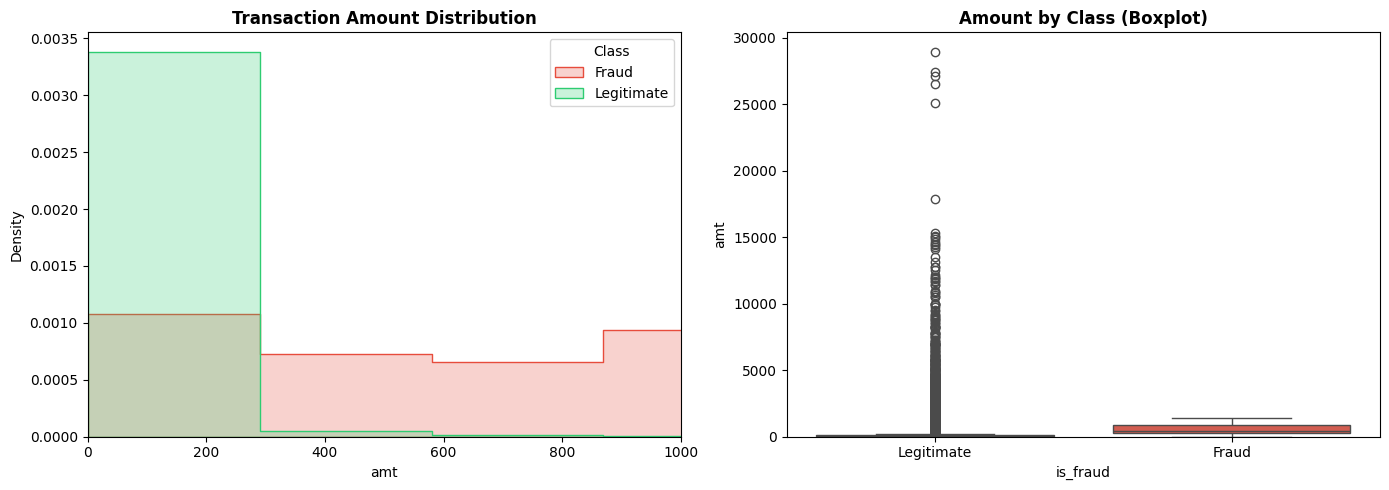

--- Amount Statistics ---


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.67,154.01,1.00,9.61,47.28,82.54,28948.90
1,7506.0,531.32,390.56,1.06,245.66,396.50,900.88,1376.04


In [79]:
ig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

# 1. Distribution Plot: Seaborn handles the 'subsetting' and 'legend' for you
sns.histplot(data=train, x='amt', hue='is_fraud', bins=100, 
             palette=colors, element='step', fill=True, 
             stat='density', common_norm=False, ax=axes[0])
axes[0].set_ylim(0, None) 
axes[0].set_xlim(0, 1000)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].legend(title='Class', labels=['Fraud', 'Legitimate'])

# 2. Box Plot: Styled to match your colors
sns.boxplot(data=train, x='is_fraud', y='amt', palette=colors, ax=axes[1])
axes[1].set_title('Amount by Class (Boxplot)', fontweight='bold')
axes[1].set_ylim(0, None) # Optional: keeps the scale readable if there are huge outliers
axes[1].set_xticklabels(['Legitimate', 'Fraud'])


plt.tight_layout()
plt.show()

# Stats Summary
print("--- Amount Statistics ---")
display(train.groupby('is_fraud')['amt'].describe().round(2))

How big are the frauds amounts?

we analyse only the frauds entries. ("is_fraud"==1)

In [80]:
tm_fraud = tm_train[tm_train["is_fraud"]==1]

fraud_hour_am = tm_fraud.groupby("hour")["amt"].sum().reset_index()
fraud_hour_am_mean = tm_fraud.groupby("hour")["amt"].mean().reset_index()
fraud_hour_am_count = tm_fraud.groupby("hour")["is_fraud"].value_counts().reset_index()


fraud_day_am = tm_fraud.groupby("day_name")["amt"].sum().reset_index()
fraud_day_am_mean = tm_fraud.groupby("day_name")["amt"].mean().reset_index()
fraud_day_am_count = tm_fraud.groupby("day_name")["is_fraud"].value_counts().reset_index()


orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fraud_day_am["day_name"] = pd.Categorical(fraud_day_am["day_name"], categories=orden, ordered=True)
fraud_day_am = fraud_day_am.sort_values("day_name").reset_index(drop=True)

fraud_day_am_mean["day_name"] = pd.Categorical(fraud_day_am_mean["day_name"], categories=orden, ordered=True)
fraud_day_am_mean = fraud_day_am_mean.sort_values("day_name").reset_index(drop=True)

fraud_day_am_count["day_name"] = pd.Categorical(fraud_day_am_mean["day_name"], categories=orden, ordered=True)
fraud_day_am_count = fraud_day_am_count.sort_values("day_name").reset_index(drop=True)


fraud_month_am = tm_fraud.groupby("month")["amt"].sum().reset_index()
fraud_month_am_mean = tm_fraud.groupby("month")["amt"].mean().reset_index()
fraud_month_am_count = tm_fraud.groupby("month")["is_fraud"].value_counts().reset_index()

In [81]:
print("--general amt description--\n", tm_train["amt"].describe()), print("--fraud amt description--\n", tm_fraud["amt"].describe())

--general amt description--
 count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64
--fraud amt description--
 count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


(None, None)

The frauds transaction have a low value amount (less than $1,400).

----------------------------------------



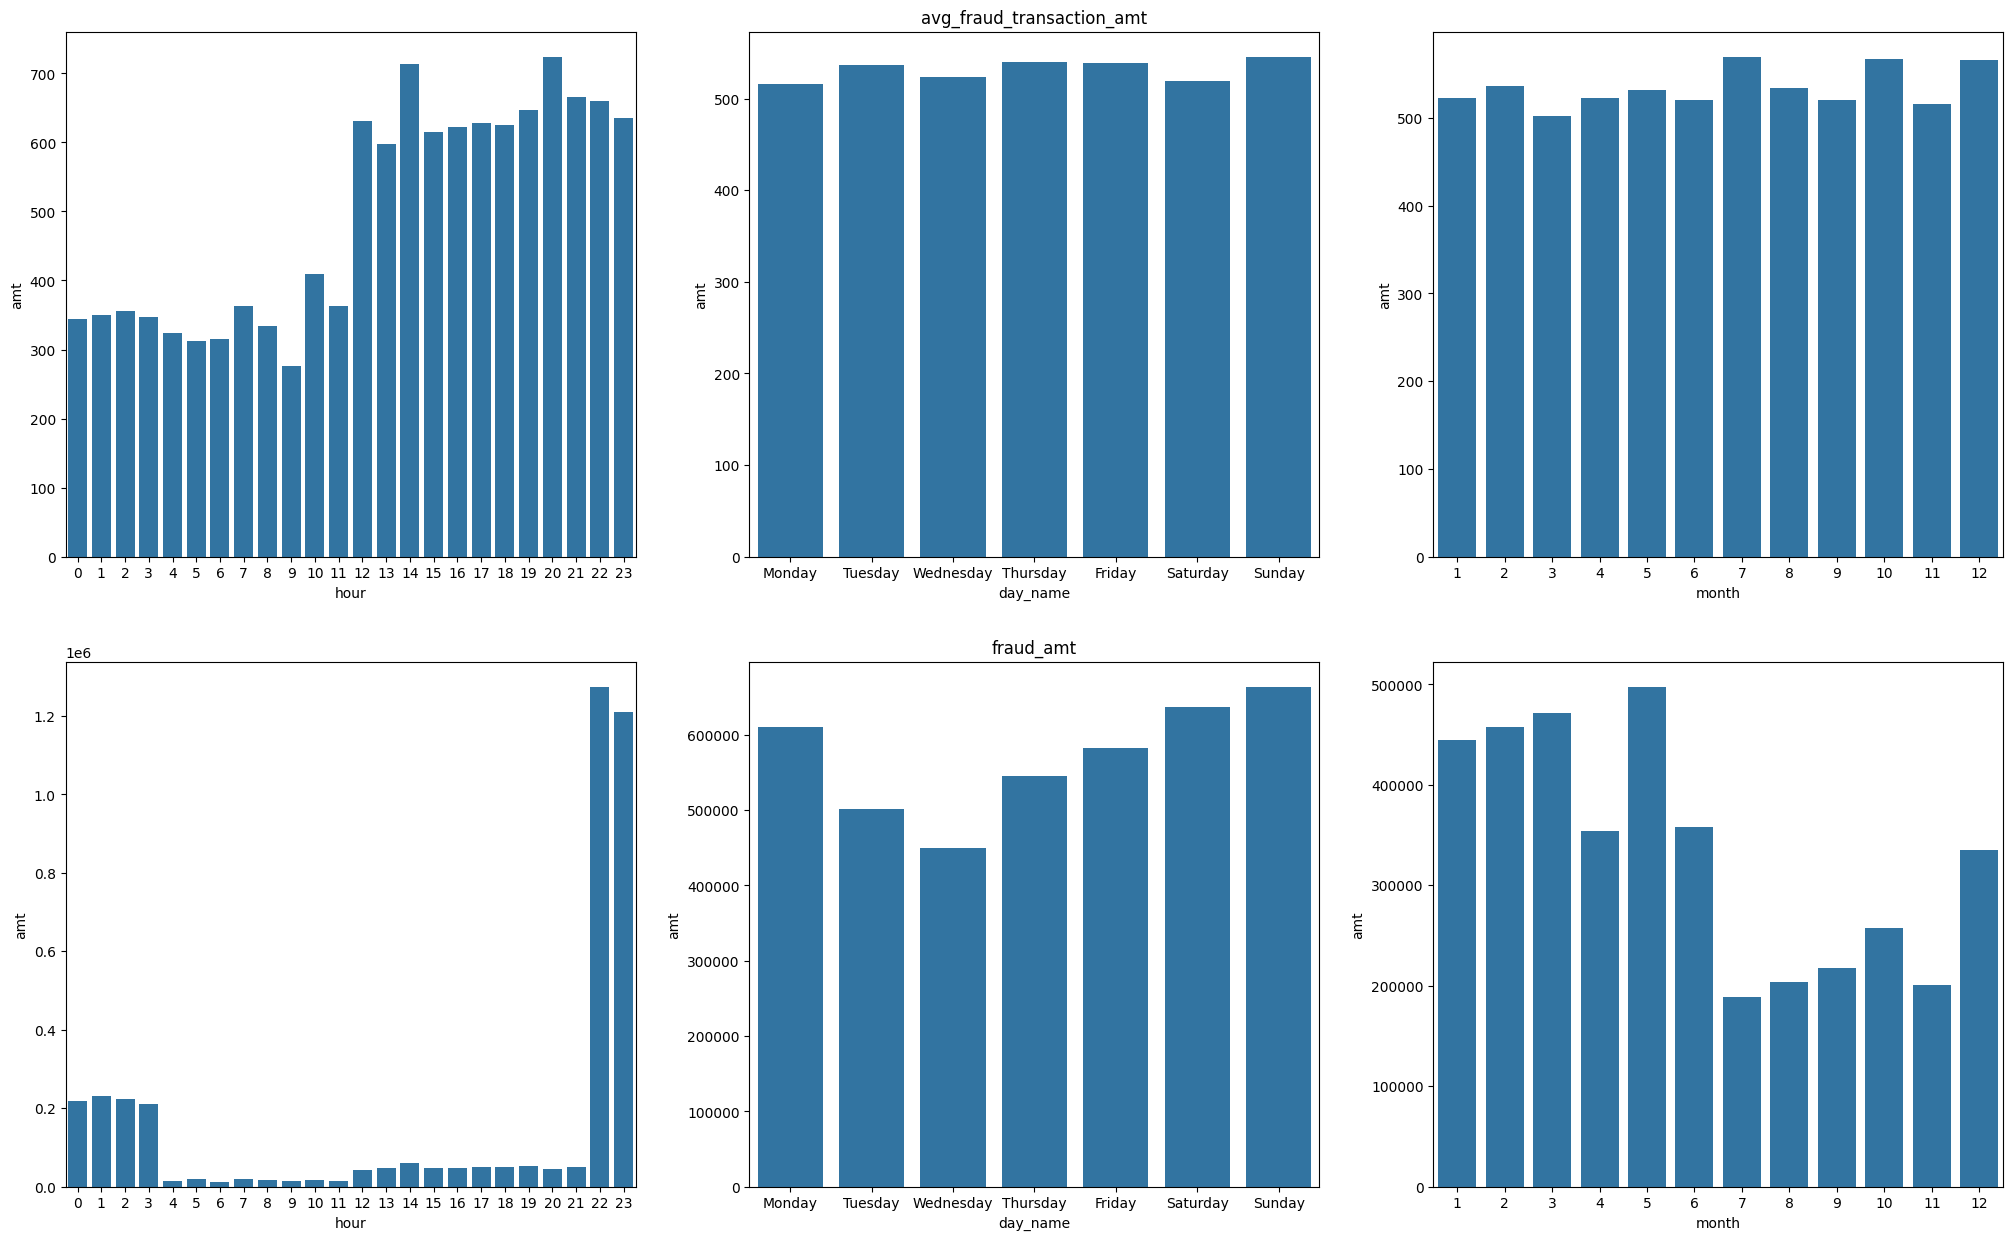

In [82]:
fig, axes = plt.subplots(nrows= 2, ncols=3, figsize=(25,15),squeeze=False)

sns.barplot(data=fraud_hour_am_mean, x="hour", y="amt", ax=axes[0,0])
sns.barplot(data=fraud_day_am_mean, x="day_name", y="amt", ax=axes[0,1])
sns.barplot(data=fraud_month_am_mean, x="month", y="amt", ax=axes[0,2])
axes[0,1].set_title("avg_fraud_transaction_amt")

sns.barplot(data=fraud_hour_am, x="hour", y="amt", ax=axes[1,0])
sns.barplot(data=fraud_day_am, x="day_name", y="amt", ax=axes[1,1])
sns.barplot(data=fraud_month_am, x="month", y="amt", ax=axes[1,2])
axes[1,1].set_title("fraud_amt")

print("--"*20)
print(f"")

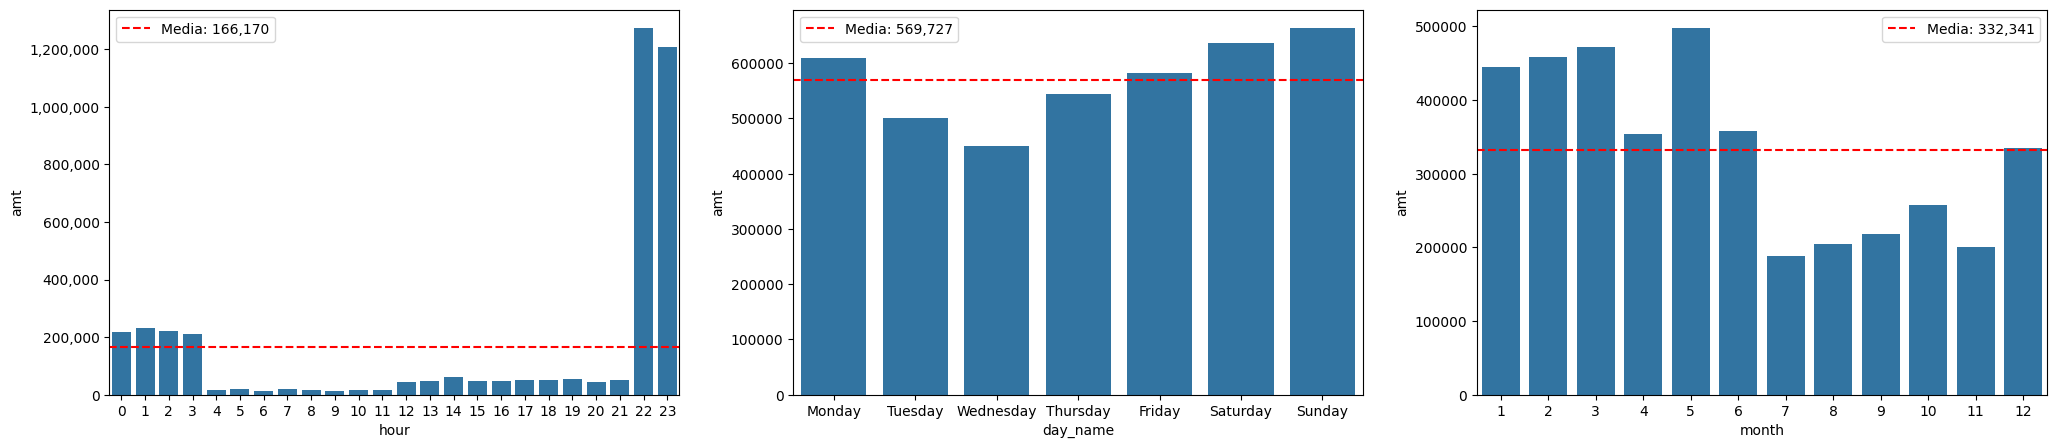

In [83]:
fig, axes = plt.subplots(nrows= 1, ncols=3, figsize=(25,5),squeeze=False)

sns.barplot(data=fraud_hour_am, x="hour", y="amt", ax=axes[0,0])
sns.barplot(data=fraud_day_am, x="day_name", y="amt", ax=axes[0,1])
sns.barplot(data=fraud_month_am, x="month", y="amt", ax=axes[0,2])

axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Línea de media en gráfica axes [0,0]
media_day = fraud_day_am["amt"].mean()
media_hour = fraud_hour_am["amt"].mean()
media_month = fraud_month_am["amt"].mean()

axes[0, 1].axhline(media_day, color="red", linestyle="--", linewidth=1.5,
                   label=f"Media: {media_day:,.0f}")
axes[0, 0].axhline(media_hour, color="red", linestyle="--", linewidth=1.5,
                   label=f"Media: {media_hour:,.0f}")
axes[0, 2].axhline(media_month, color="red", linestyle="--", linewidth=1.5,
                   label=f"Media: {media_month:,.0f}")
axes[0, 0].legend()
axes[0, 1].legend()
axes[0, 2].legend()



<Axes: xlabel='hour', ylabel='day_name'>

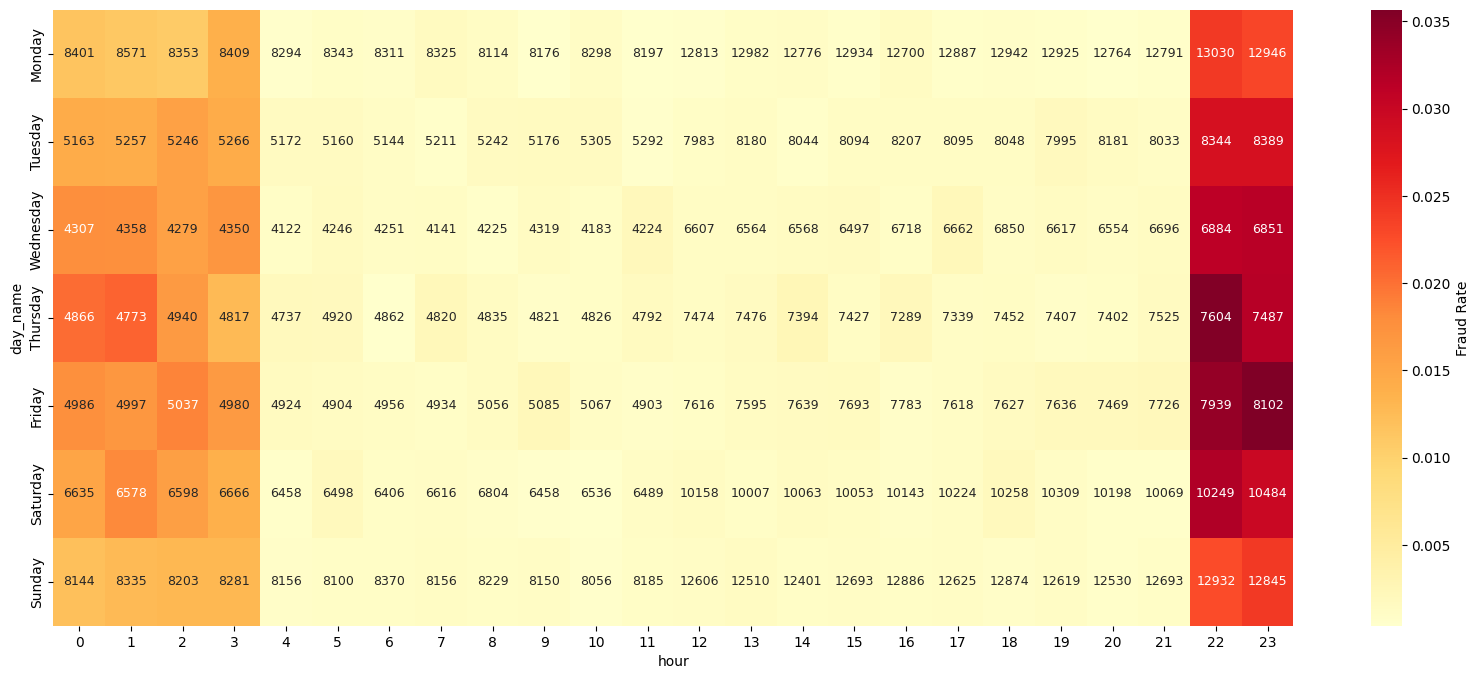

In [84]:
rate_data = tm_train.pivot_table(index="day_name", columns= "hour",values= 'is_fraud' , aggfunc= 'mean').reindex(orden)

volume_data = tm_train.pivot_table(index= "day_name", columns= "hour", values= "is_fraud", aggfunc= "count").reindex(orden)

plt.figure(figsize=(20,8))
sns.heatmap(rate_data,
            cmap='YlOrRd', 
            annot = volume_data,
            fmt='d',
            cbar_kws= {'label': "Fraud Rate"},
            annot_kws={"size": 9})

## Category risk

In [85]:
cat_fraud = train.groupby("category")["is_fraud"].agg(
    total= "count",
    fraud_rate = lambda x: x.mean() * 100,
).sort_values(by = "fraud_rate", ascending = True)

Text(0.5, 0, 'Count')

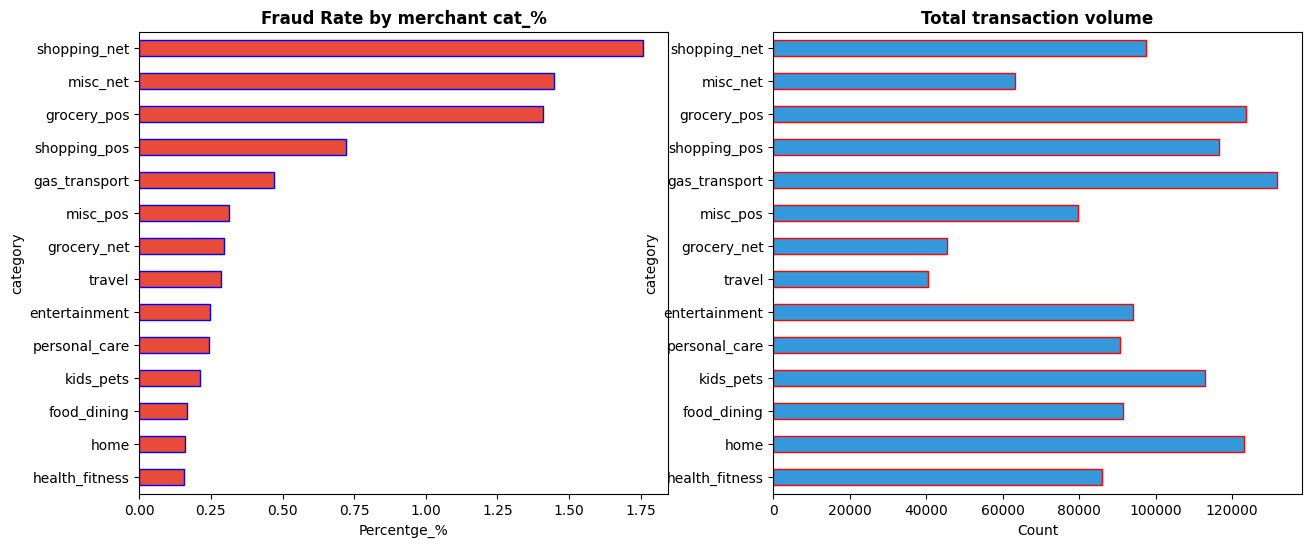

In [86]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize= (15,6))

cat_fraud["fraud_rate"].plot(kind='barh', ax=ax1,color="#e94b3a", edgecolor= "blue")
ax1.set_title("Fraud Rate by merchant cat_%", fontweight='bold')
ax1.set_xlabel("Percentge_%")

cat_fraud["total"].plot(kind= "barh", ax=ax2, color= "#3498db", edgecolor="red")
ax2.set_title("Total transaction volume", fontweight= "bold")
ax2.set_xlabel("Count")

## Geographical analysis

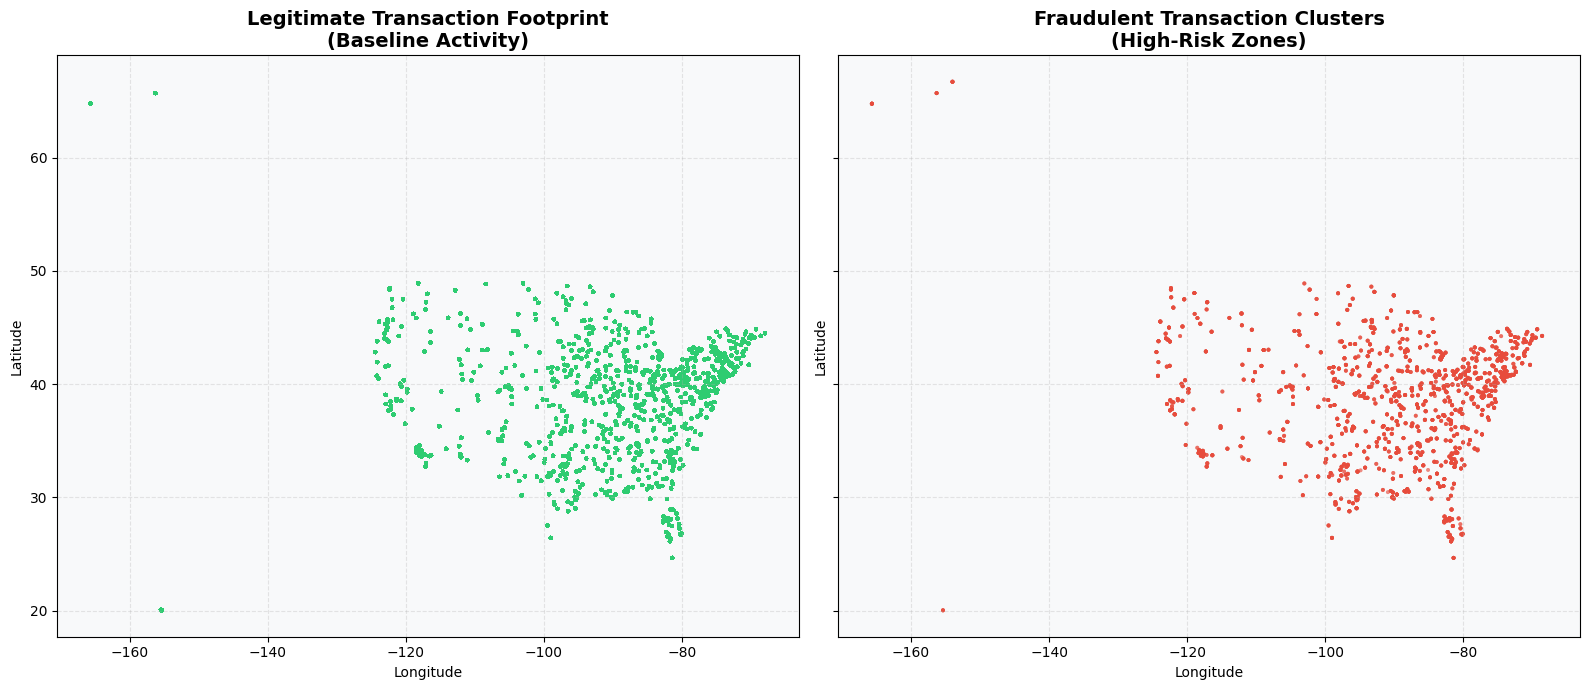

Geographic Coverage: Fraud spans 752 distinct latitudes.


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Define common styling
scatter_kwargs = {'edgecolors': 'none', 'alpha': 0.2}

# Chart 1: Legitimate Transactions (The "Normal" Footprint)
legit = train[train['is_fraud'] == 0]
axes[0].scatter(legit['long'], legit['lat'], s=8, c='#2ecc71', label='Legit', **scatter_kwargs)
axes[0].set_title('Legitimate Transaction Footprint\n(Baseline Activity)', fontsize=14, fontweight='bold')

# Chart 2: Fraudulent Transactions (The "Attack" Footprint)
fraud = train[train['is_fraud'] == 1]
axes[1].scatter(fraud['long'], fraud['lat'], s=8, c='#e74c3c', label='Fraud', alpha=0.4, edgecolors='none')
axes[1].set_title('Fraudulent Transaction Clusters\n(High-Risk Zones)', fontsize=14, fontweight='bold')

# Clean up both plots
for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_facecolor('#f8f9fa') # Light grey background to make dots pop

plt.tight_layout()
plt.show()

# Quick Insight:
print(f"Geographic Coverage: Fraud spans {fraud['lat'].nunique()} distinct latitudes.")

In [88]:
"distance between home and the merchant"

def haversine_distance(lat1,lon1,lat2,lon2):
    "distance in kilometers"
    # decimal degree to radians
    lon1,lat1,lon2,lat2 = map(np.radians,[lon1,lat1,lon2,lat2])

    dlon= lon2-lon1
    dlat = lat2 - lat1

    a= np.sin(dlat/2)**2 + np.cos(lat2)*np.cos(lat1)*np.sin(dlon/2)**2
    c= 2*np.arcsin(np.sqrt(a))
    r = 6271
    return r*c


tm_train["dist_to_merc"] = haversine_distance(tm_train["lat"],tm_train["long"],tm_train["merch_lat"],tm_train["merch_long"])

print("---Distance analysis---")

display(tm_train.groupby("is_fraud")["dist_to_merc"].describe())



---Distance analysis---


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,74.919065,28.661995,0.021905,54.464192,77.005057,96.958359,149.729523
1,7506.0,75.071213,28.301297,0.727173,54.759669,76.708725,96.846731,142.253969


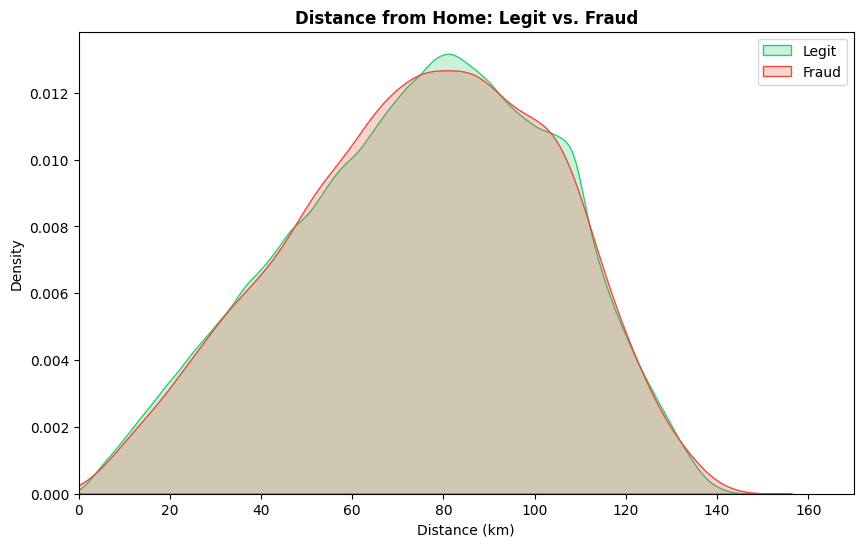

In [89]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=tm_train[tm_train['is_fraud']==0], x='dist_to_merc', label='Legit', fill=True, color='#2ecc71')
sns.kdeplot(data=tm_train[tm_train['is_fraud']==1], x='dist_to_merc', label='Fraud', fill=True, color='#e74c3c')
plt.title('Distance from Home: Legit vs. Fraud', fontweight='bold')
plt.xlabel('Distance (km)')
plt.xlim(0, 170) # Zoom in on the most relevant range
plt.legend()
plt.show()

## Age and gender 

In [90]:
tm_fraud['dob'].head()

2449   1988-09-15
2472   1960-10-28
2523   1960-10-28
2546   1988-09-15
2553   1960-10-28
Name: dob, dtype: datetime64[us]

In [91]:
tm_train.groupby("is_fraud")["city_pop"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,88775.228137,301806.545204,23.0,743.0,2456.0,20328.0,2906700.0
1,7506.0,97276.763256,326581.466670,23.0,746.5,2623.0,21437.0,2906700.0


---Age analysis---


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,46.0,17.0,13.0,32.0,43.0,57.0,95.0
1,7506.0,48.0,19.0,14.0,33.0,47.0,60.0,93.0


---city analysis---


C:\Users\Brahim\AppData\Local\Temp\ipykernel_31772\47140432.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= fraud_age, x="gr_age", y="fraud_ratio" ,palette= "Blues_d", ax=axes[0])
C:\Users\Brahim\AppData\Local\Temp\ipykernel_31772\47140432.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= fraud_gender, x= "gender", y="fraud_ratio",palette= "Reds_d",ax= axes[1])
C:\Users\Brahim\AppData\Local\Temp\ipykernel_31772\47140432.py:34: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data= fraud_pop, x="pop_group", y= "fraud_ratio", palette= "Greens_d",color="#e74c3c", marker="o", linewidth=2, ax=axes[2])


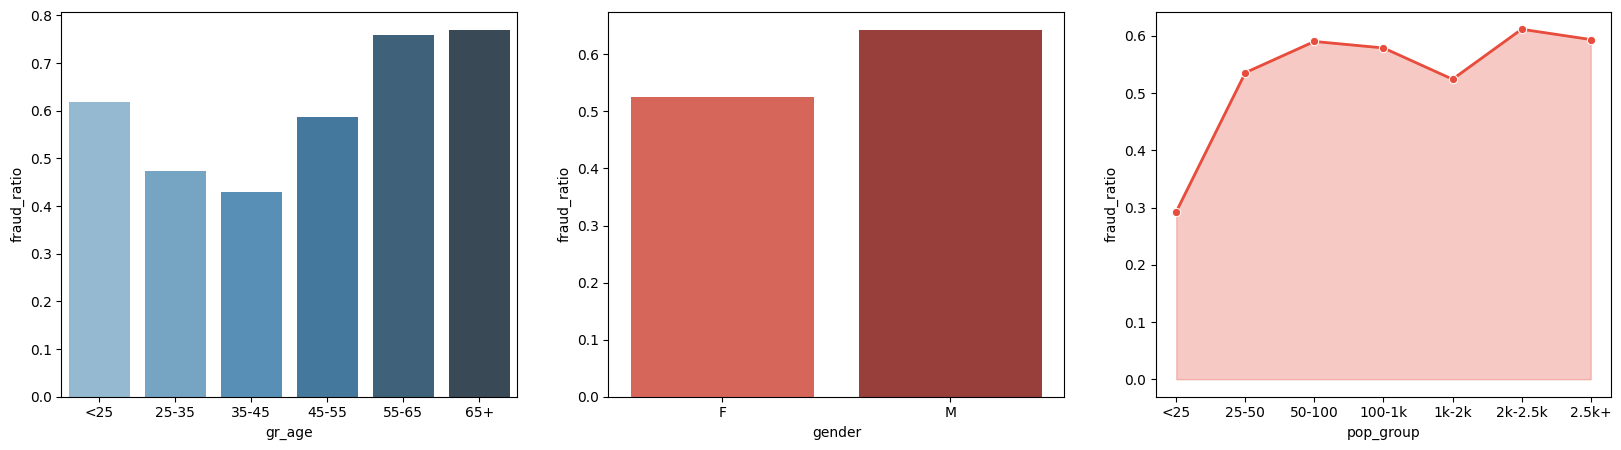

In [92]:
tm_train["age"]= (tm_train["trans_date_trans_time"] - tm_train["dob"]).dt.days//365

tm_train["gr_age"] = pd.cut(tm_train["age"],
                            bins=[0,25,35,45,55,65,150],
                            labels=['<25','25-35','35-45','45-55','55-65','65+'])

tm_train["pop_group"] = pd.cut(tm_train["city_pop"],
                               bins=[0,25,50,100,1000,2000,2500,tm_train["city_pop"].max()],
                               labels= ['<25', '25-50', '50-100', '100-1k', '1k-2k', '2k-2.5k', '2.5k+'])



print("---Age analysis---")
display(tm_train.groupby("is_fraud")["age"].describe().round(0))
print("---city analysis---")
tm_train.groupby("is_fraud")["city_pop"].describe()


fraud_age = tm_train.groupby("gr_age")["is_fraud"].mean().mul(100).reset_index()
fraud_age.columns = ["gr_age", "fraud_ratio"]


fraud_gender = tm_train.groupby("gender")["is_fraud"].mean().mul(100).reset_index()
fraud_gender.columns = ["gender", "fraud_ratio"]

fraud_pop = tm_train.groupby("pop_group")["is_fraud"].mean().mul(100).reset_index()
fraud_pop.columns = ["pop_group", "fraud_ratio"]

fig , axes = plt.subplots(1,3,  figsize= (20,5))


sns.barplot(data= fraud_age, x="gr_age", y="fraud_ratio" ,palette= "Blues_d", ax=axes[0])
sns.barplot(data= fraud_gender, x= "gender", y="fraud_ratio",palette= "Reds_d",ax= axes[1])
sns.lineplot(data= fraud_pop, x="pop_group", y= "fraud_ratio", palette= "Greens_d",color="#e74c3c", marker="o", linewidth=2, ax=axes[2])
axes[2].fill_between(range(len(fraud_pop)), fraud_pop["fraud_ratio"],
                color="#e74c3c", alpha=0.3)

+ Unvalanced target
+ Time
    - high fraud ratio between 22 - 4AM (late night).
    - The fraud ratio is picked up on Fridays, but the high fraud amounts are located at the weekend.
+ Merchant category
    - TOP 3 merchant used for fraud : shopping_net, misc_net, grocery
+ Geolocation 
    - There is no significant difference in distance between clients' places of residence and merchants.
+ Age, population
    - The fraud ratio increases when the population/age increases.
+ Gender
    - Male more fraud ratio than female

# PREPROCESSING

In [93]:
tm_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 30 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[us]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  str           
 3   category               1296675 non-null  str           
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  str           
 6   last                   1296675 non-null  str           
 7   gender                 1296675 non-null  str           
 8   street                 1296675 non-null  str           
 9   city                   1296675 non-null  str           
 10  state                  1296675 non-null  str           
 11  zip                    1296675 non-null  int64         
 12  lat                    1296675 non-null

Feuatures creation

In [94]:
def build_features_1(df):
    df = df.copy()
    # time
    df["trans_date_trans_time"]  = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"]         = pd.to_datetime(df["dob"])
    df["hour"]        = df["trans_date_trans_time"].dt.hour
    df["dayweek"]     =df["trans_date_trans_time"].dt.dayofweek
    df["month"]       =df["trans_date_trans_time"].dt.month
    df["is_night"]    = ((df["hour"]>=22) | (df["hour"]<=5)).astype(int)
    df["is_weekend"]  = (df["dayweek"]>=5).astype(int)
    df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']     = np.sin(2 * np.pi * df['dayweek'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['dayweek'] / 7)
    
    #age
    df["age"]= (df["trans_date_trans_time"] - df["dob"]).dt.days//365
    df["gr_age"] = pd.cut(df["age"],
                                bins=[0,25,35,45,55,65,150],
                                labels=[0,1,2,3,4,5]).astype(int)
    #distance
    df["geo_dist"] = haversine_distance(df["lat"],df["long"],df["merch_lat"],df["merch_long"])
    df['lat_diff']     = np.abs(df['merch_lat'] - df['lat'])
    df['lon_diff']     = np.abs(df['merch_long'] - df['long'])

    # merc category
    HIGH_RISK = ['shopping_net', 'misc_net', 'grocery_pos', 'shopping_pos']
    df['is_high_risk_cat'] = df['category'].isin(HIGH_RISK).astype(int)

    


    return df


    


In [95]:
train_1 = build_features_1(train)
test_1 = build_features_1(test)

TRANSFORMATION/ENCODERS

In [96]:
cat_feat = ["merchant","category","gender","state","job"]

for col in cat_feat:
    is_subset=set(test[col]).issubset(set(train[col]))
    new_cat= (set(test[col]) - set(train[col]))
    print(f"{col} is subset: {is_subset}, new_cat :{len(new_cat)} {new_cat}")


merchant is subset: True, new_cat :0 set()
category is subset: True, new_cat :0 set()
gender is subset: True, new_cat :0 set()
state is subset: True, new_cat :0 set()
job is subset: False, new_cat :3 {'Engineer, water', 'Operational investment banker', 'Software engineer'}


In [97]:
cat_feat = ["merchant", "category", "gender", "state", "job"]
encoders = {}

# Fit en train
for col in cat_feat:
    le = LabelEncoder()
    values = train_1[col].astype(str).tolist()
    values.append("unknown")
    le.fit(values)
    train_1[col + "_enc"] = le.transform(train_1[col].astype(str))
    encoders[col] = le

# Transform en test con manejo de unknown
for col in cat_feat:
    le = encoders[col]
    known = set(le.classes_)
    
    safe_values = np.where(
        test_1[col].astype(str).isin(known),
        test_1[col].astype(str),
        "unknown"
    )
    test_1[col + "_enc"] = le.transform(safe_values)

In [98]:
for df in [train_1,test_1] :
    df["log_amt"] = np.log1p(df["amt"])
    df["log_geo_dist"] = np.log1p(df["geo_dist"])
    df["sqrt_amt"] = np.sqrt(df["amt"])


In [99]:
feats = [c for c in train_1.columns if c not in train.columns]
feats.extend(['lat', 'long', 'merch_lat', 'merch_long', 'zip'])

In [100]:
pre_train = train_1.copy()
pre_test = test_1.copy()

x_train = pre_train[feats]
y_train= pre_train["is_fraud"]

x_test = pre_test[feats]
y_test= pre_test["is_fraud"]


Imbalanced target treatment

Using SMOTE to balance the target.

In [101]:
smote = SMOTE(random_state=42, k_neighbors=5)

[0]	validation_0-auc:0.94833
[14]	validation_0-auc:0.96555


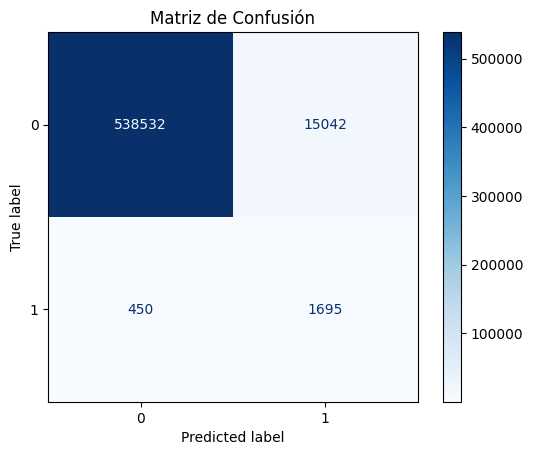

ROC-AUC score : 0.965747870062379


In [108]:
x_smote, y_smote = smote.fit_resample(x_train,y_train)

model =  XGBClassifier(max_depth = 6,
                        min_child_weight = 5,
                        subsample = 0.8,
                        colsample_bytree = 0.8,
                        n_estimators = 500,
                        learning_rate = 0.05,
                        eval_metric = "auc",
                        random_state= 42,
                        early_stopping_rounds = 10,
                        n_jobs= 2)

model.fit(x_smote,y_smote,
          eval_set= [(x_test,y_test)],
          verbose=100,
                    )

y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:,1]

cm = confusion_matrix(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_proba)


disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

print(f"ROC-AUC score : {roc_auc}")


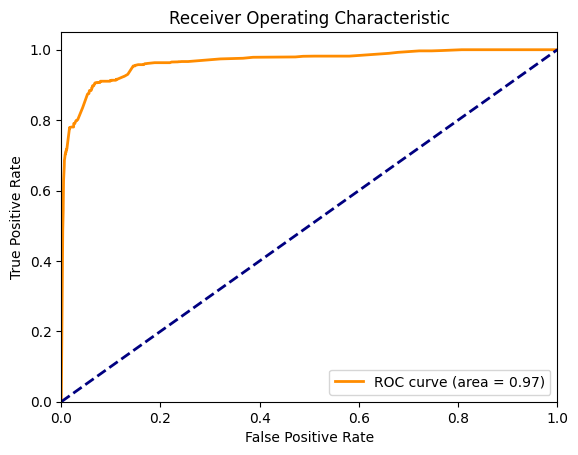

In [112]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, 

print("classification final metrics:")
print(classification_report(y_test, y_pred))

classification final metrics:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.10      0.79      0.18      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.88      0.58    555719
weighted avg       1.00      0.97      0.98    555719



**Features Importance :**

In [106]:
import xgboost as xgb

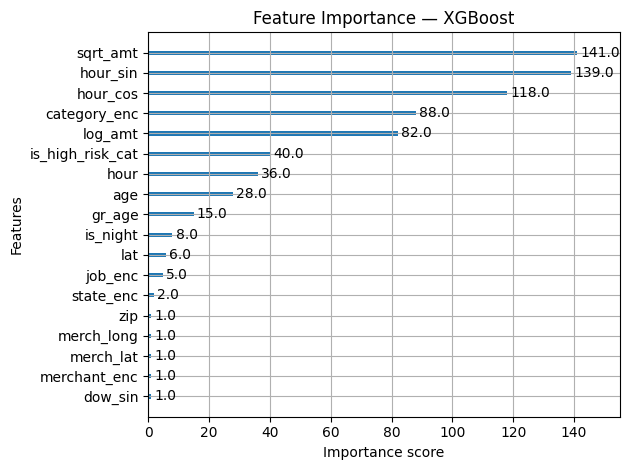

In [107]:
xgb.plot_importance(model, max_num_features=20,importance_type= "weight")
plt.title("Feature Importance — XGBoost")
plt.tight_layout()
plt.show()